# Marmousi II Elastic Forward Modeling

2D elastic wave simulation on the Marmousi II marine model, matching the [DENISE-Black-Edition](https://github.com/daniel-koehn/DENISE-Black-Edition) `pyapi_demo.ipynb` configuration.

**DENISE reference config:**
- Grid: 500 × 174, DH = 20 m
- Time: DT = 2 ms, T = 6.0 s (3000 steps)
- Source: Ricker wavelet, f₀ = 10 Hz
- PML: 10 grid points, npower = 4, Kmax = 1.0

In [13]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

using JuliWave
using PyPlot

  Activating project at `~/Workspace/juliwave/JuliWave.jl`


## Load Marmousi II Model

Load the binary Vp, Vs, and density files from the DENISE distribution.

In [14]:
denise_dir = "/home/x/Programs/denise/DENISE-Black-Edition-master/par/start"

function load_denise_binary(path, nx_file, ny_file)
    raw = Vector{Float32}(undef, nx_file * ny_file)
    open(path, "r") do io
        read!(io, raw)
    end
    return Float64.(permutedims(reshape(raw, ny_file, nx_file), (2, 1)))
end

NX_FILE, NY_FILE = 500, 174
vp = load_denise_binary(joinpath(denise_dir, "marmousi_II_marine.vp"), NX_FILE, NY_FILE)
vs = load_denise_binary(joinpath(denise_dir, "marmousi_II_marine.vs"), NX_FILE, NY_FILE)
rho = load_denise_binary(joinpath(denise_dir, "marmousi_II_marine.rho"), NX_FILE, NY_FILE)

500×174 Matrix{Float64}:
 1010.0  1010.0  1010.0  1010.0  1010.0  …  2430.0  2430.0  2430.0  2430.0
 1010.0  1010.0  1010.0  1010.0  1010.0     2430.0  2430.0  2430.0  2407.0
 1010.0  1010.0  1010.0  1010.0  1010.0     2430.0  2430.0  2407.0  2407.0
 1010.0  1010.0  1010.0  1010.0  1010.0     2430.0  2407.0  2407.0  2407.0
 1010.0  1010.0  1010.0  1010.0  1010.0     2430.0  2407.0  2407.0  2407.0
 1010.0  1010.0  1010.0  1010.0  1010.0  …  2407.0  2407.0  2407.0  2407.0
 1010.0  1010.0  1010.0  1010.0  1010.0     2407.0  2407.0  2407.0  2407.0
 1010.0  1010.0  1010.0  1010.0  1010.0     2407.0  2407.0  2407.0  2475.0
 1010.0  1010.0  1010.0  1010.0  1010.0     2407.0  2407.0  2475.0  2475.0
 1010.0  1010.0  1010.0  1010.0  1010.0     2407.0  2407.0  2475.0  2475.0
    ⋮                                    ⋱     ⋮                    
 1010.0  1010.0  1010.0  1010.0  1010.0     2392.0  2435.0  2435.0  2435.0
 1010.0  1010.0  1010.0  1010.0  1010.0     2392.0  2392.0  2435.0  2435.0
 1010.

## Visualize the Velocity Model

In [15]:
imshow(transpose(vp))
gcf();

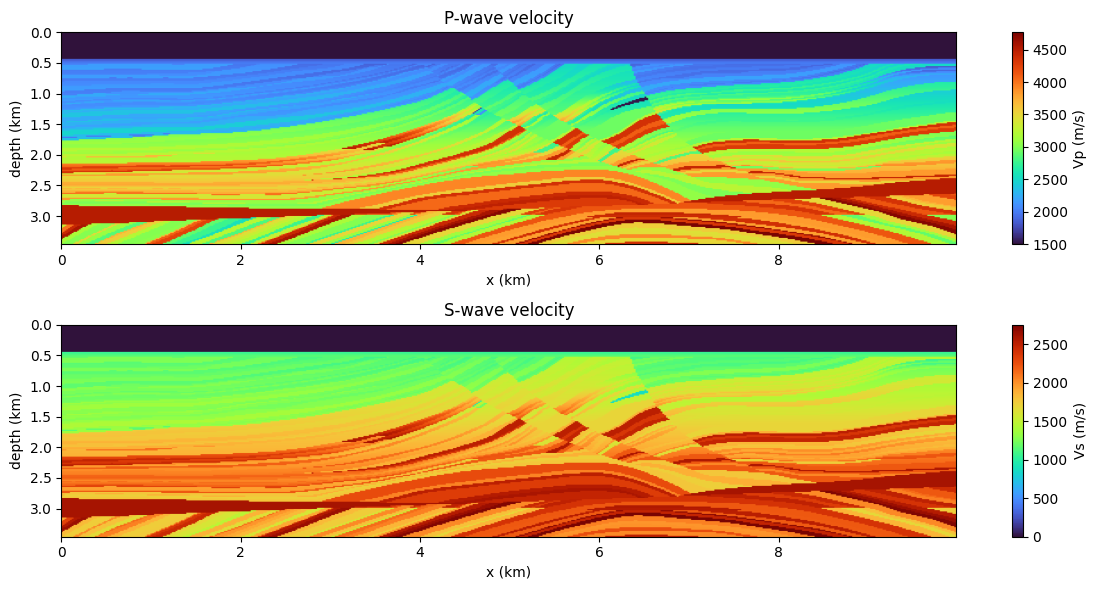

In [16]:
dx = 20.0
nx, ny = NX_FILE, NY_FILE
x_km = (0:nx-1) .* dx ./ 1e3
y_km = (0:ny-1) .* dx ./ 1e3
extent = [x_km[1], x_km[end], y_km[end], y_km[1]]

figure(figsize=(12, 6))

subplot(2, 1, 1)
imshow(vp'; aspect="auto", cmap="turbo", extent=extent)
colorbar(label="Vp (m/s)")
title("P-wave velocity"); xlabel("x (km)"); ylabel("depth (km)")

subplot(2, 1, 2)
imshow(vs'; aspect="auto", cmap="turbo", extent=extent)
colorbar(label="Vs (m/s)")
title("S-wave velocity"); xlabel("x (km)"); ylabel("depth (km)")

tight_layout()
gcf()

## Set Up Grid, Acquisition, and Simulation

Configure the grid, source/receiver geometry, and time stepping to match the DENISE reference.

In [17]:
grid = Grid2D(nx, ny, dx, dx)
model = ElasticModel2D(vp, vs, rho, grid)

# Acquisition geometry
f0 = 10.0  # Hz

# Sources: x = 800–8720 m, spacing 160 m, depth 40 m
src_x = collect(800.0:160.0:8720.0)
src_depth = 40.0

# Receivers: x = 800–8780 m, spacing 20 m, depth 460 m
rec_x = collect(800.0:20.0:8780.0)
rec_depth = 460.0
receivers = [Receiver(x, rec_depth) for x in rec_x]

# Time stepping (matching DENISE)
dt = 2.0e-3   # 2 ms
nt = 3000      # T = 6.0 s
config = SimulationConfig(nt, dt; pml_points=10, pml_npower=4.0, pml_kmax=1.0, space_order=8)

courant = check_cfl(maximum(vp), dt, dx, dx; space_order=8)
println("$(length(src_x)) sources, $(length(receivers)) receivers")
println("dt = $(dt*1e3) ms, nt = $nt, T = $(nt*dt) s")
println("Courant number: $(round(courant, digits=4))")

50 sources, 400 receivers
dt = 2.0 ms, nt = 3000, T = 6.0 s
Courant number: 0.8671


## Visualize Acquisition Geometry

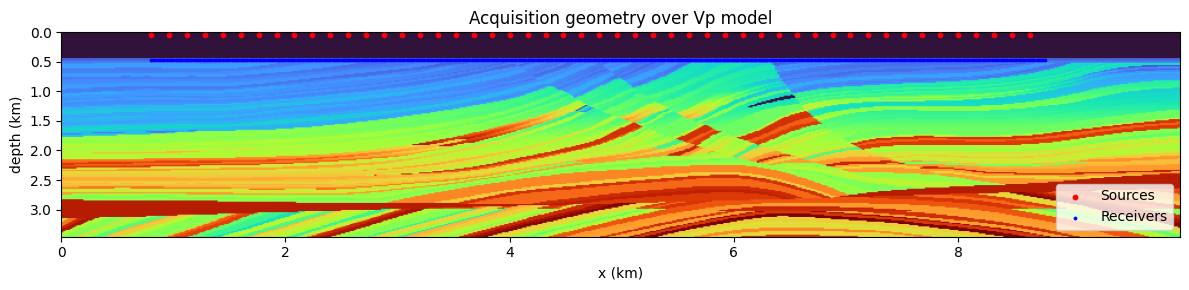

In [18]:
figure(figsize=(12, 3))
imshow(vp'; aspect="auto", cmap="turbo", extent=extent)
scatter(src_x ./ 1e3, fill(src_depth / 1e3, length(src_x));
    c="red", s=10, label="Sources", zorder=3)
scatter(rec_x ./ 1e3, fill(rec_depth / 1e3, length(rec_x));
    c="blue", s=3, label="Receivers", zorder=3)
legend(loc="lower right")
title("Acquisition geometry over Vp model")
xlabel("x (km)"); ylabel("depth (km)")
tight_layout()
gcf()

## Run Forward Simulation (Single Shot)

Run the first shot with wavefield snapshots saved every 150 time steps (0.3 s).

In [19]:
shot_idx = 1
wavelet = RickerWavelet(f0; amplitude=1.0)
src = PointSource(src_x[shot_idx], src_depth, wavelet; angle=0.0)
geometry = Geometry([src], receivers)

snap_interval = 150  # every 0.3 s

@time seis_vx, seis_vy, snaps_vx, snaps_vy = simulate_elastic_wavefield(
    model, geometry, config; save_every=snap_interval)

  1.790005 seconds (308.31 k allocations: 75.946 MiB, 0.26% gc time, 17.60% compilation time)


([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 1.0693822054392024e-10 4.1541668531060034e-11 … 6.140017128603875e-11 1.3575153932996936e-10; 1.0719518077469183e-10 3.2140835565324074e-11 … 3.9886510342763786e-11 9.279158409293122e-11], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 2.0665978200312703e-10 1.4384793164435429e-10 … -3.690611154011258e-10 -5.186367733316338e-10; 2.156028845759016e-10 1.340856170775828e-10 … -3.0119900101818783e-10 -5.289011189256617e-10], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; … ;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0;;; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.

In [20]:
size(snaps_vx) 

(500, 174, 20)

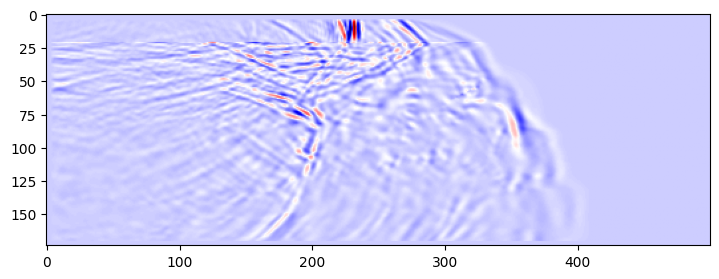

In [27]:
figure(figsize=(12, 3))
imshow(snaps_vx[:, :, 10]', cmap="seismic")
gcf()